In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_parquet('/content/drive/MyDrive/Mining of massive dataset/preprocessing_output/yellow_2014/01_flow.parquet')
df.head(1)

,time_bin,pulocationid,dolocationid,flow_count
0,2014-01-01,4,4,3


In [ ]:
import pandas as pd

df = pd.read_parquet('/content/drive/MyDrive/Mining of massive dataset/data_yellow/2014/yellow_tripdata_2014-01.parquet')
df.head(1)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2014-01-01 00:02:00,2014-01-01 00:04:00,6,0.0,1,None,146,146,1,3.5,0.5,0.5,0.02,0.0,0.0,4.52,NaN,None


In [ ]:
pip install geopandas

In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np

def create_grid_lookup(shapefile_path, output_csv):
    print("Đang đọc dữ liệu Shapefile...")
    zones = gpd.read_file(shapefile_path)

    zones = zones.to_crs(epsg=4326)

    zones['centroid_lon'] = zones.geometry.centroid.x
    zones['centroid_lat'] = zones.geometry.centroid.y

    lon_min, lon_max = zones['centroid_lon'].min(), zones['centroid_lon'].max()
    lat_min, lat_max = zones['centroid_lat'].min(), zones['centroid_lat'].max()
    print(f"Khung tọa độ NYC - Lon: [{lon_min:.4f}, {lon_max:.4f}], Lat: [{lat_min:.4f}, {lat_max:.4f}]")

    GRID_X_BINS = 10
    GRID_Y_BINS = 20

    grid_x_size = (lon_max - lon_min) / GRID_X_BINS
    grid_y_size = (lat_max - lat_min) / GRID_Y_BINS

    zones['Grid_X'] = np.floor((zones['centroid_lon'] - lon_min) / grid_x_size).astype(int)
    zones['Grid_Y'] = np.floor((zones['centroid_lat'] - lat_min) / grid_y_size).astype(int)

    zones['Grid_X'] = zones['Grid_X'].clip(0, GRID_X_BINS - 1)
    zones['Grid_Y'] = zones['Grid_Y'].clip(0, GRID_Y_BINS - 1)

    lookup_table = zones[['LocationID', 'Grid_X', 'Grid_Y']]

    lookup_table.to_csv(output_csv, index=False)
    print(f"Hoàn tất! Bảng tra cứu lưới đã lưu tại: {output_csv}")

create_grid_lookup('/content/drive/MyDrive/Mining of massive dataset/taxi_zones', '/content/drive/MyDrive/Mining of massive dataset/preprocessing_output/taxi_zone_lookup_grid.csv')

Đang đọc dữ liệu Shapefile...
Khung tọa độ NYC - Lon: [-74.2335, -73.7110], Lat: [40.5255, 40.8995]
Hoàn tất! Bảng tra cứu lưới đã lưu tại: /content/drive/MyDrive/Mining of massive dataset/preprocessing_output/taxi_zone_lookup_grid.csv


/tmp/ipykernel_925/1311816296.py:11: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  zones['centroid_lon'] = zones.geometry.centroid.x
/tmp/ipykernel_925/1311816296.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  zones['centroid_lat'] = zones.geometry.centroid.y


In [ ]:
read_csv = pd.read_csv('/content/drive/MyDrive/Mining of massive dataset/preprocessing_output/taxi_zone_lookup_grid.csv')
read_csv.head(10)

,LocationID,Grid_X,Grid_Y
0,1,1,8
1,2,7,4
2,3,7,18
3,4,4,10
4,5,0,1
5,6,3,4
6,7,6,12
7,8,5,13
8,9,8,12
9,10,8,8


In [ ]:
read_ouput = pd.read_parquet('/content/drive/MyDrive/Mining of massive dataset/preprocessing_output/testing_2015/yellow_tripdata_2015-01_flow.parquet')
print(read_ouput.head())

print(read_ouput.dtypes)

Danh sách các Time Bin thực tế:
<DatetimeArray>
['2015-01-01 00:00:00', '2015-01-01 00:30:00', '2015-01-01 01:00:00',
 '2015-01-01 01:30:00', '2015-01-01 02:00:00', '2015-01-01 02:30:00',
 '2015-01-01 03:00:00', '2015-01-01 03:30:00', '2015-01-01 04:00:00',
 '2015-01-01 04:30:00']
Length: 10, dtype: datetime64[us]
------------------------------
Dữ liệu lúc 8h sáng trở đi:
                 time_bin  pulocationid  dolocationid  flow_count
56864 2015-01-01 08:00:00             4            17           2
56865 2015-01-01 08:00:00             4            41           1
56866 2015-01-01 08:00:00             4            50           1
56867 2015-01-01 08:00:00             4            61           1
56868 2015-01-01 08:00:00             4            74           1


TOP 5 KHU VỰC CÓ NHU CẦU GỌI XE CAO NHẤT (START VOLUME)
Top 255: Williamsburg (North Side) (Brooklyn) - Lượng xe: 79,668 chuyến
Top 7: Astoria (Queens) - Lượng xe: 73,456 chuyến
Top 74: East Harlem North (Manhattan) - Lượng xe: 73,099 chuyến
Top 41: Central Harlem (Manhattan) - Lượng xe: 71,285 chuyến
Top 75: East Harlem South (Manhattan) - Lượng xe: 68,643 chuyến


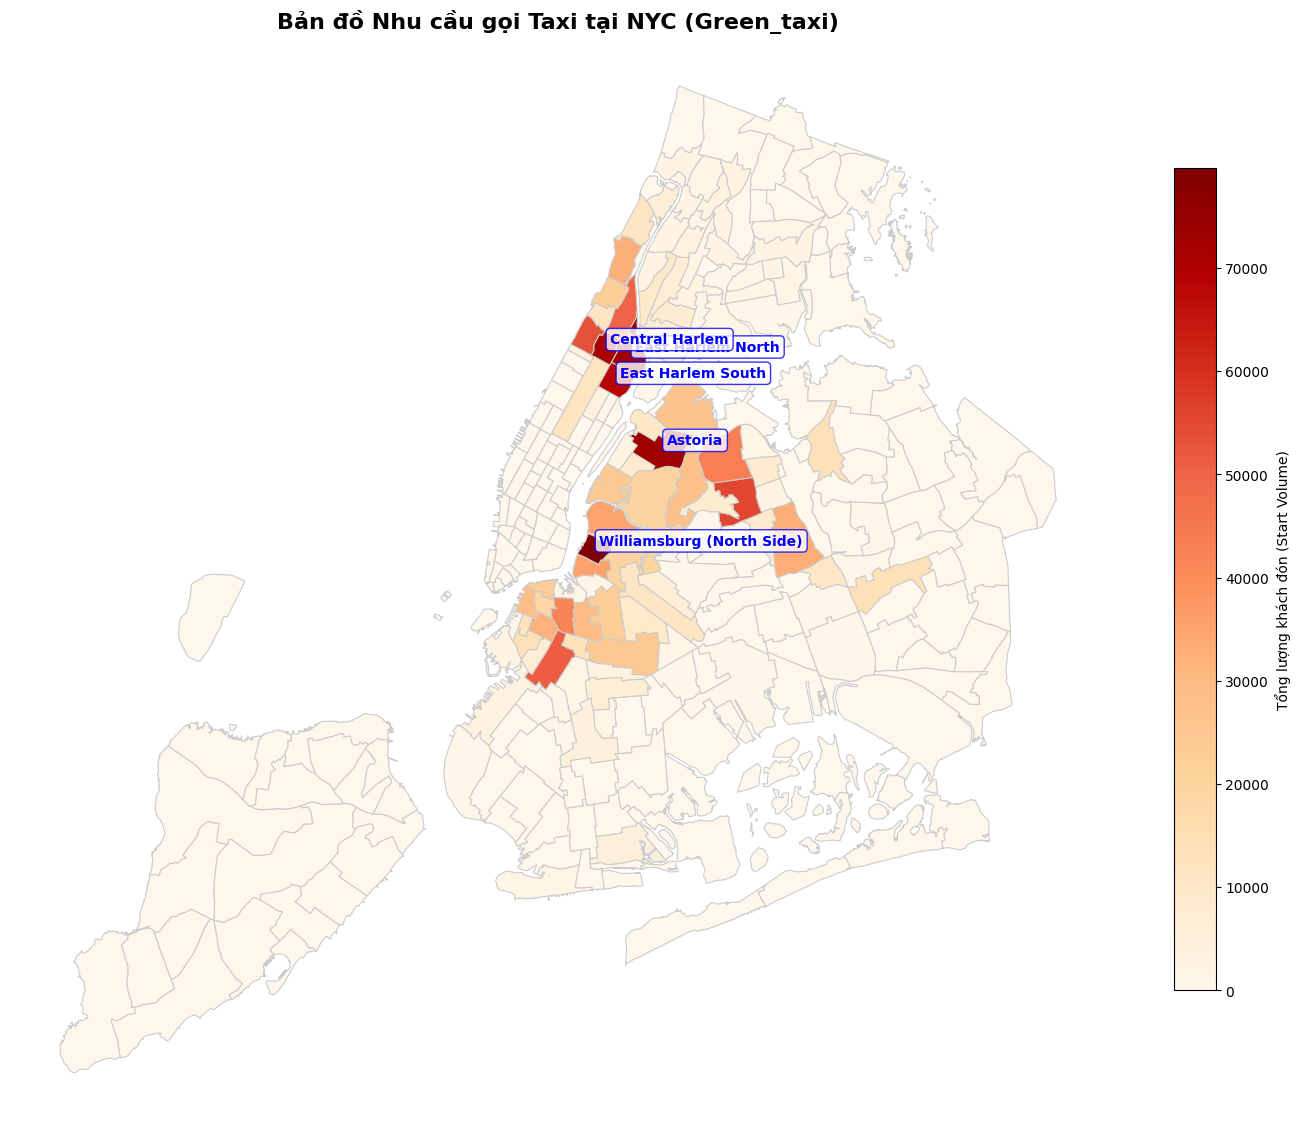

In [22]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

def plot_volume_with_insights(shapefile_path, volume_csv_path, lookup_csv_path):
    nyc_map = gpd.read_file(shapefile_path)
    df_vol = pd.read_csv(volume_csv_path)
    df_lookup = pd.read_csv(lookup_csv_path)

    total_demand = df_vol.groupby('locationid')['start_volume'].sum().reset_index()

    nyc_map = nyc_map.merge(total_demand, left_on='LocationID', right_on='locationid', how='left')
    nyc_map = nyc_map.merge(df_lookup, on='LocationID', how='left')
    nyc_map['start_volume'] = nyc_map['start_volume'].fillna(0)

    top_5_zones = nyc_map[nyc_map['LocationID'] <= 263].nlargest(5, 'start_volume')

    print("TOP 5 KHU VỰC CÓ NHU CẦU GỌI XE CAO NHẤT (START VOLUME)")
    for index, row in top_5_zones.iterrows():
        print(f"Top {index+1}: {row['Zone']} ({row['Borough']}) - Lượng xe: {int(row['start_volume']):,} chuyến")


    fig, ax = plt.subplots(1, 1, figsize=(14, 14))
    nyc_map_valid = nyc_map[nyc_map['LocationID'] <= 263]

    nyc_map_valid.plot(column='start_volume', cmap='OrRd', linewidth=0.8, ax=ax, edgecolor='0.8',
                       legend=True, legend_kwds={'shrink': 0.6, 'label': "Tổng lượng khách đón (Start Volume)"})

    for _, row in top_5_zones.iterrows():
        centroid = row.geometry.centroid
        ax.annotate(text=row['Zone'],
                    xy=(centroid.x, centroid.y),
                    xytext=(3, 3), textcoords="offset points",
                    fontsize=10, fontweight='bold', color='blue',
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="blue", alpha=0.8))

    ax.set_title('Bản đồ Nhu cầu gọi Taxi tại NYC (Green_taxi)', fontsize=16, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

plot_volume_with_insights('/content/drive/MyDrive/Mining of massive dataset/taxi_zones/taxi_zones.shp', '/content/drive/MyDrive/Mining of massive dataset/preprocessing_output/green_data/green_2015/01_volume.csv', '/content/drive/MyDrive/Mining of massive dataset/taxi_zone_lookup.csv')

TOP 5 'HUYẾT MẠCH GIAO THÔNG' QUAN TRỌNG NHẤT (PAGERANK)
Top 162: Midtown East (Manhattan) - Điểm PR: 0.0284
Top 234: Union Sq (Manhattan) - Điểm PR: 0.0266
Top 142: Lincoln Square East (Manhattan) - Điểm PR: 0.0212
Top 211: SoHo (Manhattan) - Điểm PR: 0.0155
Top 7: Astoria (Queens) - Điểm PR: 0.0147


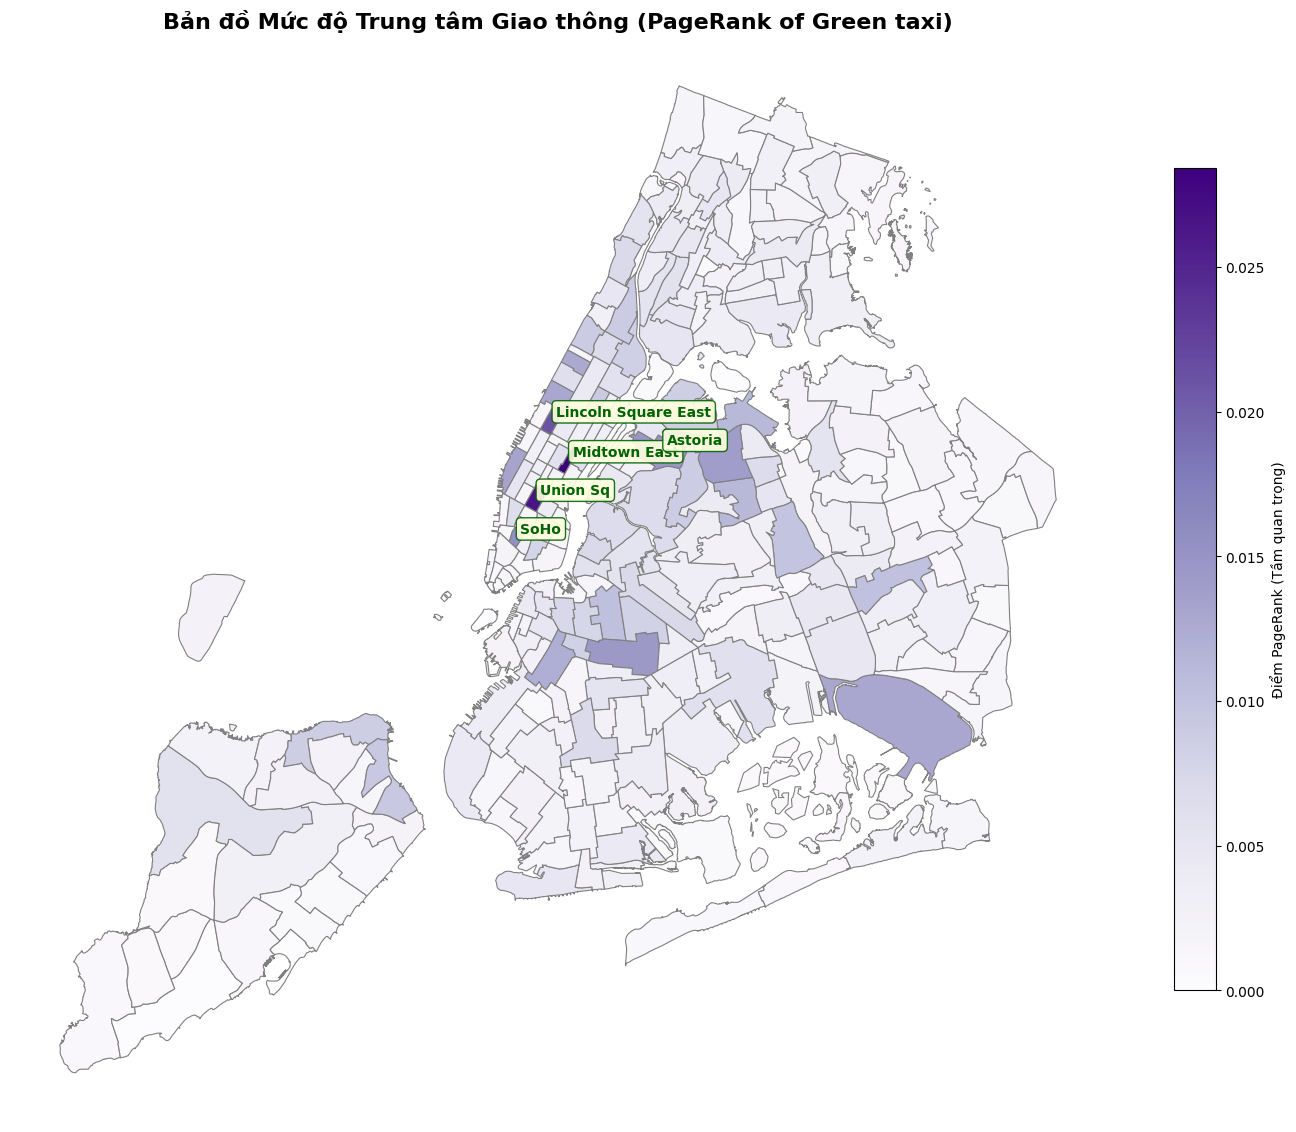

In [23]:
import pandas as pd
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt

def plot_pagerank_with_insights(shapefile_path, flow_parquet_path, lookup_csv_path):
    df_flow = pd.read_parquet(flow_parquet_path)
    df_lookup = pd.read_csv(lookup_csv_path)

    edges = df_flow.groupby(['pulocationid', 'dolocationid'])['flow_count'].sum().reset_index()

    G = nx.DiGraph()
    for _, row in edges.iterrows():
        u, v, weight = int(row['pulocationid']), int(row['dolocationid']), float(row['flow_count'])
        if u <= 263 and v <= 263:
            G.add_edge(u, v, weight=weight)

    pagerank_scores = nx.pagerank(G, weight='weight')
    df_pr = pd.DataFrame(list(pagerank_scores.items()), columns=['LocationID', 'PageRank_Score'])

    nyc_map = gpd.read_file(shapefile_path)
    nyc_map = nyc_map.merge(df_pr, on='LocationID', how='left').fillna(0)
    nyc_map = nyc_map.merge(df_lookup, on='LocationID', how='left')

    top_5_pr = nyc_map[nyc_map['LocationID'] <= 263].nlargest(5, 'PageRank_Score')

    print("TOP 5 'HUYẾT MẠCH GIAO THÔNG' QUAN TRỌNG NHẤT (PAGERANK)")
    for index, row in top_5_pr.iterrows():
        print(f"Top {index+1}: {row['Zone']} ({row['Borough']}) - Điểm PR: {row['PageRank_Score']:.4f}")

    fig, ax = plt.subplots(1, 1, figsize=(14, 14))
    nyc_map_valid = nyc_map[nyc_map['LocationID'] <= 263]

    nyc_map_valid.plot(column='PageRank_Score', cmap='Purples', linewidth=0.8, ax=ax, edgecolor='0.5',
                       legend=True, legend_kwds={'shrink': 0.6, 'label': "Điểm PageRank (Tầm quan trọng)"})

    for _, row in top_5_pr.iterrows():
        centroid = row.geometry.centroid
        ax.annotate(text=row['Zone'],
                    xy=(centroid.x, centroid.y),
                    xytext=(3, 3), textcoords="offset points",
                    fontsize=10, fontweight='bold', color='darkgreen',
                    bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="darkgreen", alpha=0.9))

    ax.set_title('Bản đồ Mức độ Trung tâm Giao thông (PageRank of Green taxi)', fontsize=16, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

plot_pagerank_with_insights('/content/drive/MyDrive/Mining of massive dataset/taxi_zones/taxi_zones.shp', '/content/drive/MyDrive/Mining of massive dataset/preprocessing_output/green_data/green_2015/01_flow.parquet', '/content/drive/MyDrive/Mining of massive dataset/taxi_zone_lookup.csv')

TOP 5 KHU VỰC CÓ NHU CẦU GỌI XE CAO NHẤT (START VOLUME)
Top 237: Upper East Side South (Manhattan) - Lượng xe: 465,095 chuyến
Top 161: Midtown Center (Manhattan) - Lượng xe: 443,714 chuyến
Top 236: Upper East Side North (Manhattan) - Lượng xe: 439,573 chuyến
Top 79: East Village (Manhattan) - Lượng xe: 435,492 chuyến
Top 230: Times Sq/Theatre District (Manhattan) - Lượng xe: 426,107 chuyến


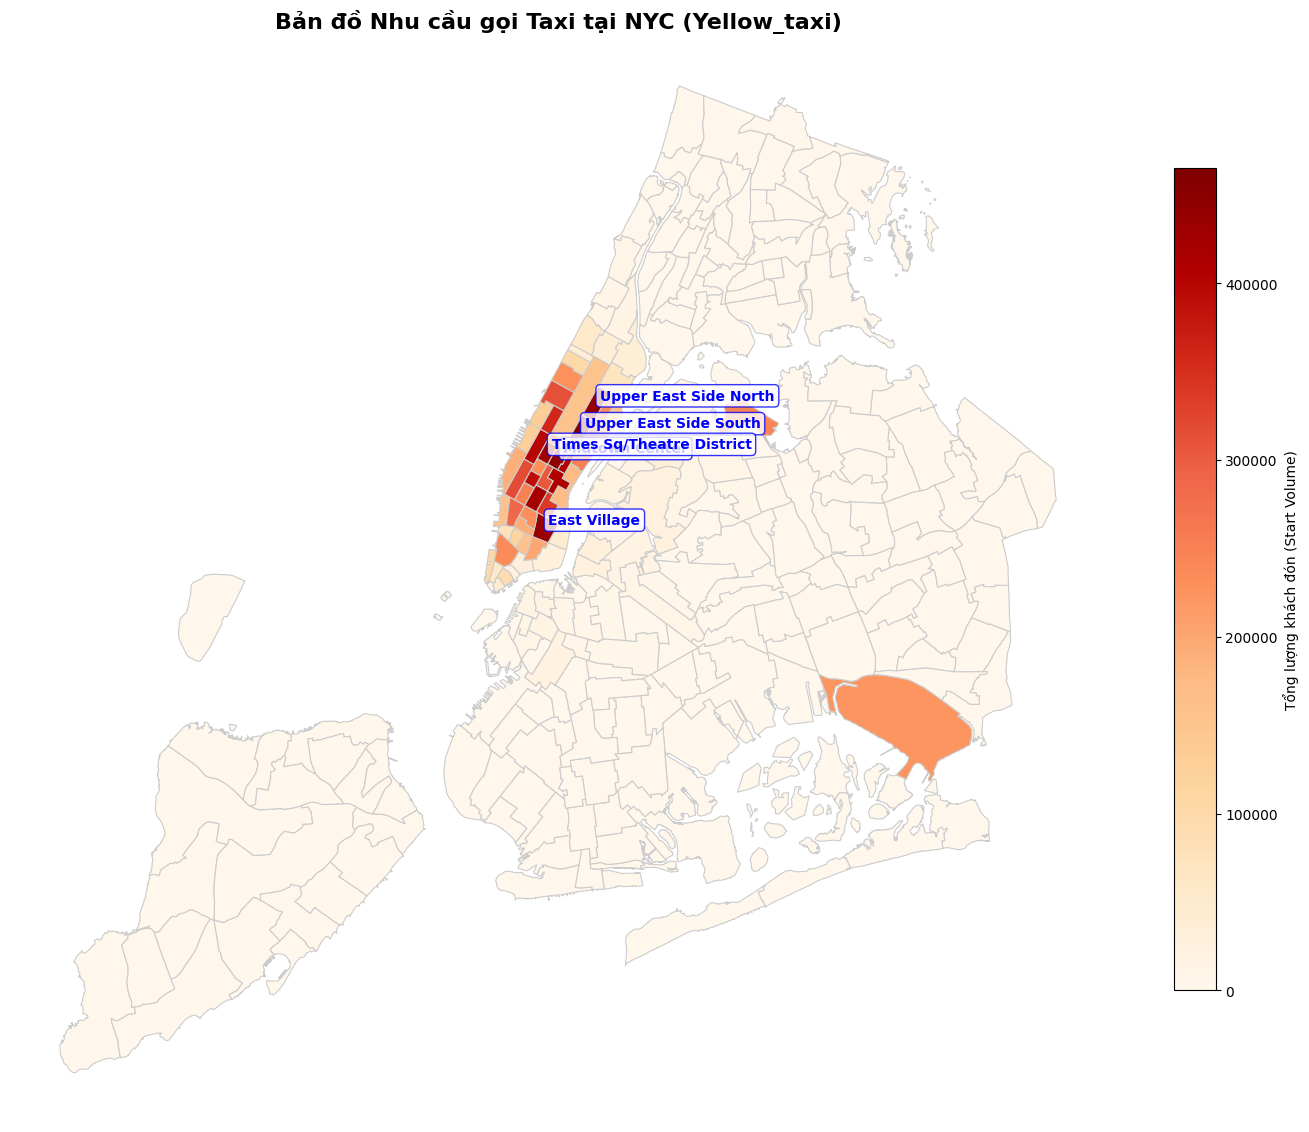

In [20]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

def plot_volume_with_insights(shapefile_path, volume_csv_path, lookup_csv_path):
    nyc_map = gpd.read_file(shapefile_path)
    df_vol = pd.read_csv(volume_csv_path)
    df_lookup = pd.read_csv(lookup_csv_path)

    total_demand = df_vol.groupby('locationid')['start_volume'].sum().reset_index()

    nyc_map = nyc_map.merge(total_demand, left_on='LocationID', right_on='locationid', how='left')
    nyc_map = nyc_map.merge(df_lookup, on='LocationID', how='left')
    nyc_map['start_volume'] = nyc_map['start_volume'].fillna(0)

    top_5_zones = nyc_map[nyc_map['LocationID'] <= 263].nlargest(5, 'start_volume')

    print("TOP 5 KHU VỰC CÓ NHU CẦU GỌI XE CAO NHẤT (START VOLUME)")
    for index, row in top_5_zones.iterrows():
        print(f"Top {index+1}: {row['Zone']} ({row['Borough']}) - Lượng xe: {int(row['start_volume']):,} chuyến")


    fig, ax = plt.subplots(1, 1, figsize=(14, 14))
    nyc_map_valid = nyc_map[nyc_map['LocationID'] <= 263]

    nyc_map_valid.plot(column='start_volume', cmap='OrRd', linewidth=0.8, ax=ax, edgecolor='0.8',
                       legend=True, legend_kwds={'shrink': 0.6, 'label': "Tổng lượng khách đón (Start Volume)"})

    for _, row in top_5_zones.iterrows():
        centroid = row.geometry.centroid
        ax.annotate(text=row['Zone'],
                    xy=(centroid.x, centroid.y),
                    xytext=(3, 3), textcoords="offset points",
                    fontsize=10, fontweight='bold', color='blue',
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="blue", alpha=0.8))

    ax.set_title('Bản đồ Nhu cầu gọi Taxi tại NYC (Yellow_taxi)', fontsize=16, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

plot_volume_with_insights('/content/drive/MyDrive/Mining of massive dataset/taxi_zones/taxi_zones.shp', '/content/drive/MyDrive/Mining of massive dataset/preprocessing_output/yellow_data/yellow_2015/01_volume.csv', '/content/drive/MyDrive/Mining of massive dataset/taxi_zone_lookup.csv')

TOP 5 'HUYẾT MẠCH GIAO THÔNG' QUAN TRỌNG NHẤT (PAGERANK)
Top 161: Midtown Center (Manhattan) - Điểm PR: 0.0192
Top 236: Upper East Side North (Manhattan) - Điểm PR: 0.0190
Top 237: Upper East Side South (Manhattan) - Điểm PR: 0.0168
Top 230: Times Sq/Theatre District (Manhattan) - Điểm PR: 0.0167
Top 170: Murray Hill (Manhattan) - Điểm PR: 0.0165


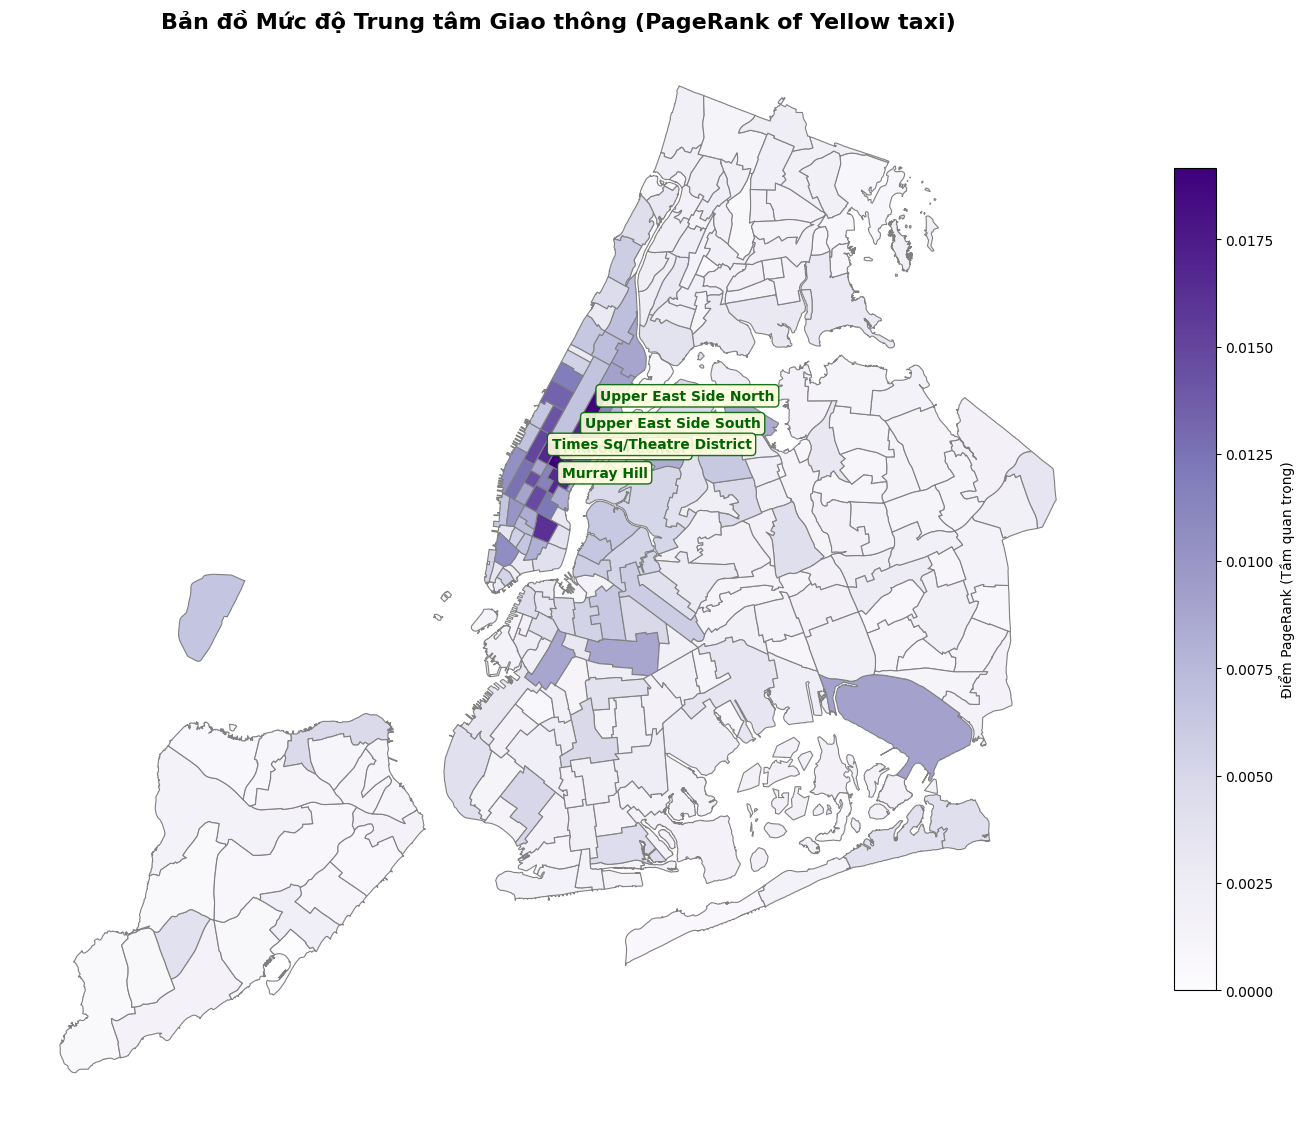

In [21]:
import pandas as pd
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt

def plot_pagerank_with_insights(shapefile_path, flow_parquet_path, lookup_csv_path):
    df_flow = pd.read_parquet(flow_parquet_path)
    df_lookup = pd.read_csv(lookup_csv_path)

    edges = df_flow.groupby(['pulocationid', 'dolocationid'])['flow_count'].sum().reset_index()

    G = nx.DiGraph()
    for _, row in edges.iterrows():
        u, v, weight = int(row['pulocationid']), int(row['dolocationid']), float(row['flow_count'])
        if u <= 263 and v <= 263:
            G.add_edge(u, v, weight=weight)

    pagerank_scores = nx.pagerank(G, weight='weight')
    df_pr = pd.DataFrame(list(pagerank_scores.items()), columns=['LocationID', 'PageRank_Score'])

    nyc_map = gpd.read_file(shapefile_path)
    nyc_map = nyc_map.merge(df_pr, on='LocationID', how='left').fillna(0)
    nyc_map = nyc_map.merge(df_lookup, on='LocationID', how='left')

    top_5_pr = nyc_map[nyc_map['LocationID'] <= 263].nlargest(5, 'PageRank_Score')

    print("TOP 5 'HUYẾT MẠCH GIAO THÔNG' QUAN TRỌNG NHẤT (PAGERANK)")
    for index, row in top_5_pr.iterrows():
        print(f"Top {index+1}: {row['Zone']} ({row['Borough']}) - Điểm PR: {row['PageRank_Score']:.4f}")

    fig, ax = plt.subplots(1, 1, figsize=(14, 14))
    nyc_map_valid = nyc_map[nyc_map['LocationID'] <= 263]

    nyc_map_valid.plot(column='PageRank_Score', cmap='Purples', linewidth=0.8, ax=ax, edgecolor='0.5',
                       legend=True, legend_kwds={'shrink': 0.6, 'label': "Điểm PageRank (Tầm quan trọng)"})

    for _, row in top_5_pr.iterrows():
        centroid = row.geometry.centroid
        ax.annotate(text=row['Zone'],
                    xy=(centroid.x, centroid.y),
                    xytext=(3, 3), textcoords="offset points",
                    fontsize=10, fontweight='bold', color='darkgreen',
                    bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="darkgreen", alpha=0.9))

    ax.set_title('Bản đồ Mức độ Trung tâm Giao thông (PageRank of Yellow taxi)', fontsize=16, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

plot_pagerank_with_insights('/content/drive/MyDrive/Mining of massive dataset/taxi_zones/taxi_zones.shp', '/content/drive/MyDrive/Mining of massive dataset/preprocessing_output/yellow_data/yellow_2015/01_flow.parquet', '/content/drive/MyDrive/Mining of massive dataset/taxi_zone_lookup.csv')

  -> Đã tìm ra 61 cặp vùng có hành vi di chuyển giống nhau > 50.0%


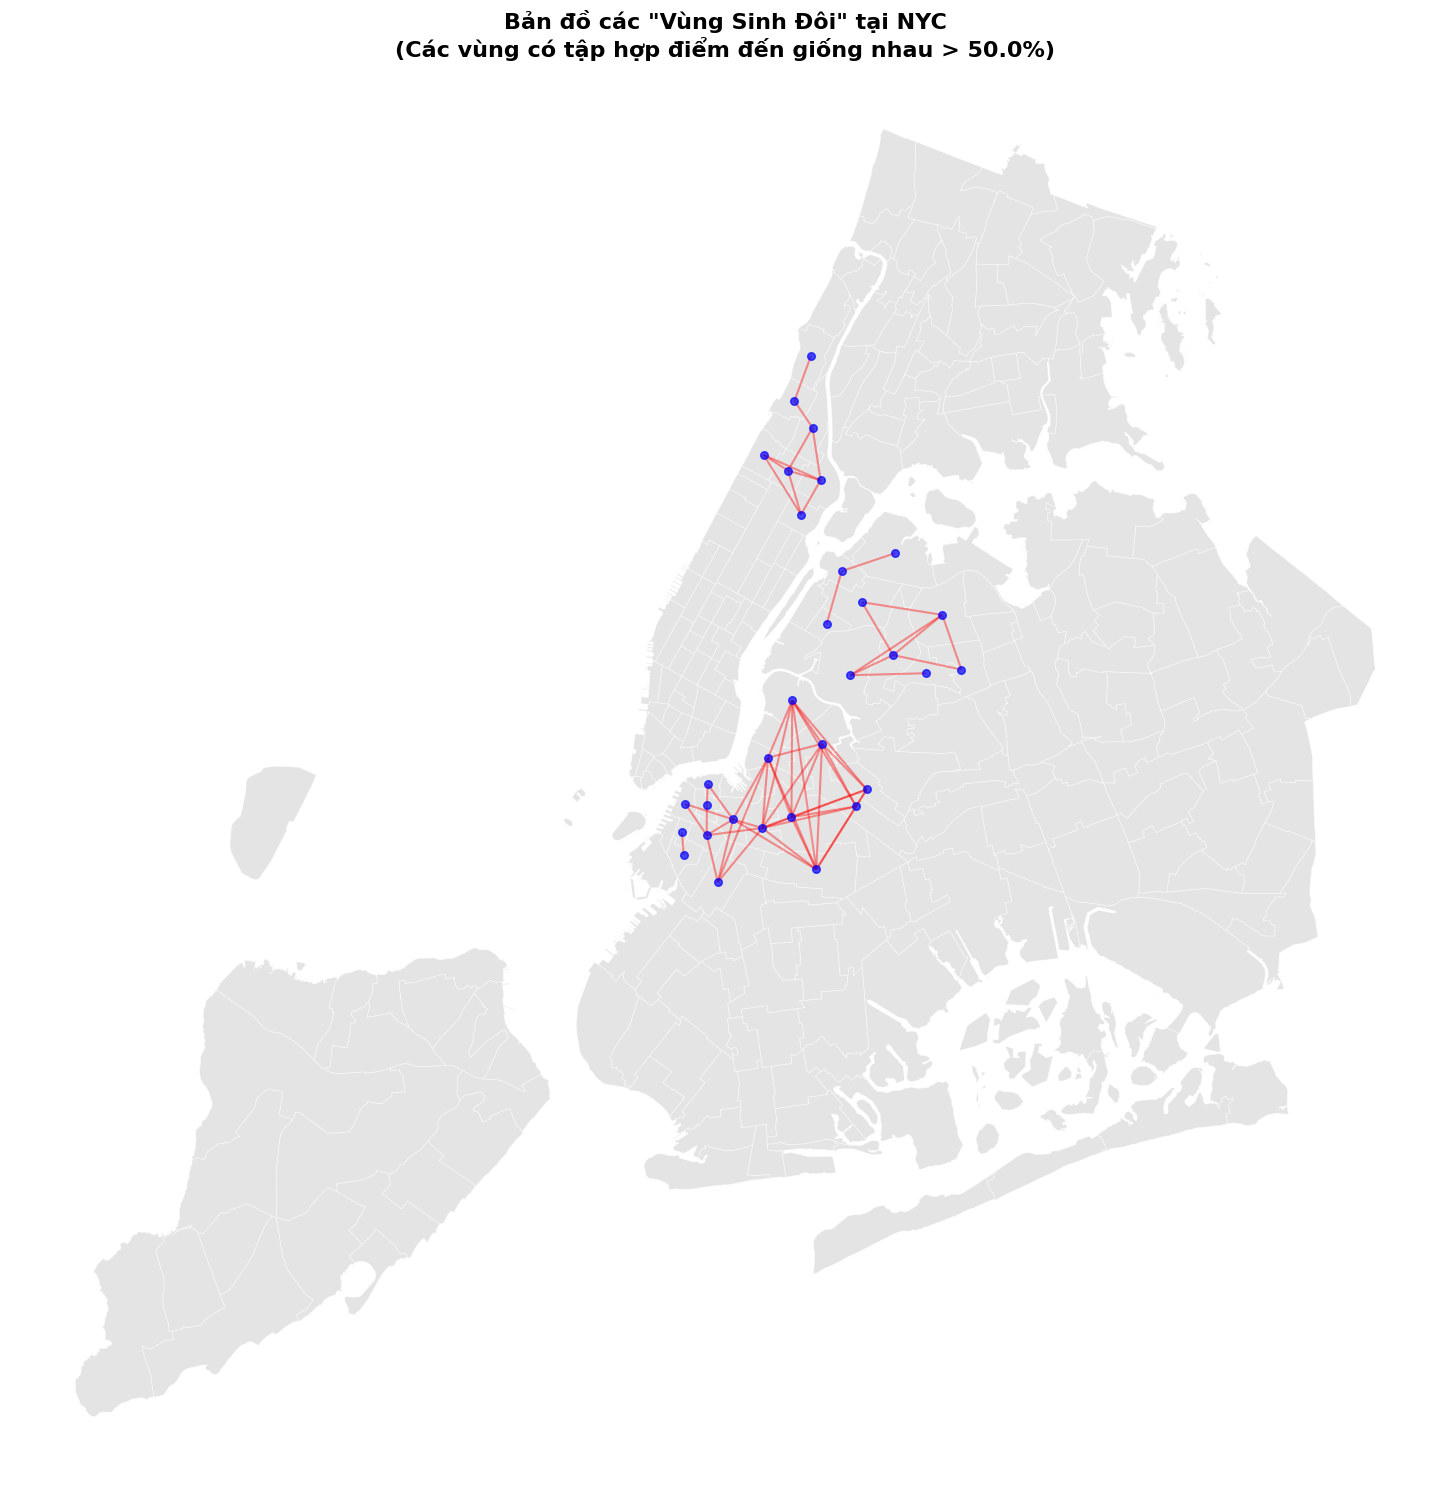

Khu vực điển hình nhất: Clinton Hill (ID: 49)
   Vùng này có mô hình di chuyển giống hệt với 10 vùng khác trong thành phố.
   -> Kết luận: Đây chính là cơ sở dữ liệu để xây dựng Semantic View trong bài báo DMVST-Net.
      Mạng Neural sẽ gom chung vector của các vùng này lại với nhau vì chúng có cùng nhịp điệu sinh hoạt!



In [26]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
from itertools import combinations

def plot_minhash_similarity(shapefile_path, flow_parquet_path, lookup_csv_path, similarity_threshold=0.6):
    df_flow = pd.read_parquet(flow_parquet_path)
    nyc_map = gpd.read_file(shapefile_path)
    df_lookup = pd.read_csv(lookup_csv_path)

    df_flow = df_flow[df_flow['flow_count'] >= 5]

    zone_sets = df_flow.groupby('pulocationid')['dolocationid'].apply(set).to_dict()

    edges = []
    for zone_a, zone_b in combinations(zone_sets.keys(), 2):
        set_a = zone_sets[zone_a]
        set_b = zone_sets[zone_b]

        if len(set_a) < 5 or len(set_b) < 5:
            continue

        intersection = len(set_a.intersection(set_b))
        union = len(set_a.union(set_b))
        jaccard_sim = intersection / union if union > 0 else 0

        if jaccard_sim >= similarity_threshold:
            edges.append((zone_a, zone_b, jaccard_sim))

    print(f"  -> Đã tìm ra {len(edges)} cặp vùng có hành vi di chuyển giống nhau > {similarity_threshold*100}%")

    fig, ax = plt.subplots(1, 1, figsize=(15, 15))

    nyc_map_valid = nyc_map[nyc_map['LocationID'] <= 263]
    nyc_map_valid.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.5, alpha=0.6)

    G = nx.Graph()
    for u, v, sim in edges:
        if u <= 263 and v <= 263:
            G.add_edge(u, v, weight=sim)

    centroids = {row['LocationID']: (row.geometry.centroid.x, row.geometry.centroid.y)
                 for _, row in nyc_map_valid.iterrows()}

    pos = {node: centroids[node] for node in G.nodes() if node in centroids}

    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='red', alpha=0.4, width=1.5)

    nx.draw_networkx_nodes(G, pos, ax=ax, node_color='blue', node_size=30, alpha=0.7)

    ax.set_title(f'Bản đồ các "Vùng Sinh Đôi" tại NYC\n(Các vùng có tập hợp điểm đến giống nhau > {similarity_threshold*100}%)',
                 fontsize=16, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

    print("="*60)
    if len(G.nodes) > 0:
        degree_dict = dict(G.degree())
        top_node = max(degree_dict, key=degree_dict.get)
        top_node_name = df_lookup[df_lookup['LocationID'] == top_node]['Zone'].values[0]

        print(f"Khu vực điển hình nhất: {top_node_name} (ID: {top_node})")
        print(f"   Vùng này có mô hình di chuyển giống hệt với {degree_dict[top_node]} vùng khác trong thành phố.")
        print("   -> Kết luận: Đây chính là cơ sở dữ liệu để xây dựng Semantic View trong bài báo DMVST-Net.")
        print("      Mạng Neural sẽ gom chung vector của các vùng này lại với nhau vì chúng có cùng nhịp điệu sinh hoạt!")
    else:
        print("Không tìm thấy cặp vùng nào vượt qua ngưỡng Similarity đã chọn. Hãy thử giảm tham số similarity_threshold xuống.")
    print("="*60 + "\n")

plot_minhash_similarity('/content/drive/MyDrive/Mining of massive dataset/taxi_zones/taxi_zones.shp', '/content/drive/MyDrive/Mining of massive dataset/preprocessing_output/green_data/green_2015/01_flow.parquet', '/content/drive/MyDrive/Mining of massive dataset/taxi_zone_lookup.csv', similarity_threshold=0.5)